# 03 — RQ1 exploratory analysis

This notebook explores the **differences between adults with HICP and those with chronic pain without high impact before model fitting**.

The predictor sets were specified before this analysis and are not selected based on their relationship with the target. The purpose of the EDA is therefore to understand the data and support interpretation of the later model results.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

rq1_df = pd.read_csv("../data/processed/rq1_model_ready.csv")

rq1_df.shape

(5465, 21)

In [2]:
# Check target distribution in the prepared dataset
rq1_df["hicp"].value_counts()

hicp
False    3557
True     1908
Name: count, dtype: int64

----

## Pain intensity and HICP

The first part of RQ1 asks whether pain intensity alone is enough to distinguish HICP from non-HICP chronic pain.

Before fitting Model 0, the relationship between pain intensity and HICP is examined descriptively.

In [3]:
# HICP proportion within each pain-intensity level
pain_intensity_hicp = pd.crosstab(rq1_df["pain_intensity_ord"], rq1_df["hicp"], normalize="index") * 100

pain_intensity_hicp

hicp,False,True
pain_intensity_ord,,
1.0,88.149499,11.850501
2.0,73.072497,26.927503
3.0,38.898353,61.101647


The recoded pain-intensity levels (also present in notebook 02) are:

- **1 = "a little"**
- **2 = "somewhere in between"**
- **3 = "a lot"**

As the table shows:
- **The proportion of respondents with HICP increases with pain intensity.**
- Pain intensity is clearly associated with HICP: the proportion of respondents classified as HICP increases from ~11.9% (those reporting "a little" pain) to 61.1% among those reporting "a lot" of pain.

*However, pain intensity and impact are not interchangeable!*  
-> Even among respondents reporting "a lot" of pain, 38.9% do not meet the HICP definition, while some respondents with lower pain intensity do.

> **This suggests that pain intensity is informative, but may not be sufficient on its own to distinguish HICP from non-HICP chronic pain: which will be tested formally in Model 0.**

### Visualising the relationship

The table above shows a clear increase in the proportion of HICP as pain intensity rises. The bar chart below makes this pattern easier to compare visually.

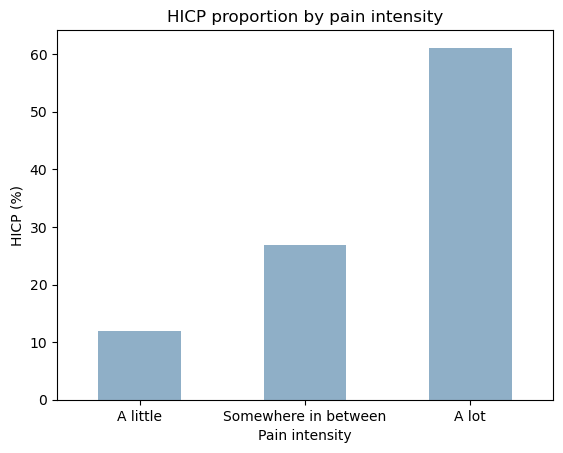

In [4]:
# Keep only the HICP percentage for each pain-intensity level
hicp_by_intensity = pain_intensity_hicp[True]

# Plot HICP percentage by pain-intensity level
ax = hicp_by_intensity.plot(kind="bar", color="#8FAFC7")

ax.set_xlabel("Pain intensity")
ax.set_ylabel("HICP (%)")
ax.set_title("HICP proportion by pain intensity")
ax.set_xticklabels(
    ["A little", "Somewhere in between", "A lot"],
    rotation=0
)

plt.show()

----

## Basic clinical information and HICP

Model A adds age, sex and reported pain location to pain intensity.

The following checks explore how these variables differ between HICP and non-HICP chronic pain before model fitting.

### Age

In [5]:
# Compare age between HICP and non-HICP respondents
age_summary = (rq1_df.groupby("hicp")["AGEP_A"].agg(["count", "mean", "median", "std"]).round(1))

age_summary

,count,mean,median,std
hicp,,,,
False,3557,59.5,62.0,16.9
True,1908,61.9,64.0,15.5


People with HICP seem to be slightly older overall: the mean age is 61.9 vs. 59.5 years, and the median is 64 vs. 62.

Still, a difference of around 2 years is not huge, especially considering how wide the age range is. So, before reading too much into it, it makes sense to look at how age is actually distributed in both groups.

In [6]:
# Check age range and skewness in both groups
age_distribution = (rq1_df.groupby("hicp")["AGEP_A"].agg(["min", "max", "skew"]).round(2))

age_distribution

,min,max,skew
hicp,,,
False,18.0,85.0,-0.46
True,18.0,85.0,-0.60


**Both groups range from 18 to 85 years, so there is clearly a lot of variation in age.**

Skewness is negative in both groups (-0.46 for non-HICP and -0.60 for HICP), meaning the distributions are slightly more concentrated at older ages, with a longer tail towards younger ages.

The skewness is not extreme, so age does not appear to have a severely distorted distribution.

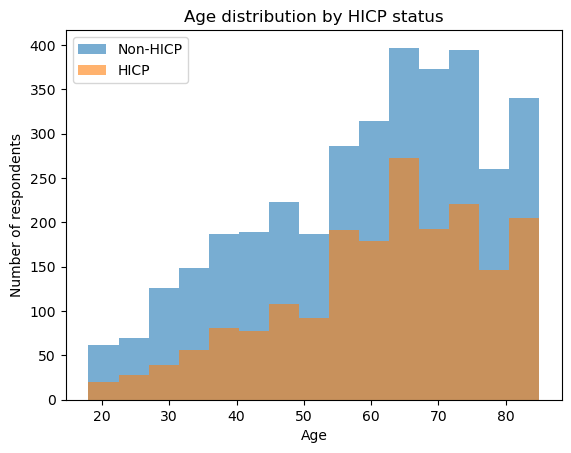

In [7]:
# Compare the age distributions
plt.hist(
    rq1_df.loc[rq1_df["hicp"] == False, "AGEP_A"],
    bins=15,
    alpha=0.6,
    label="Non-HICP"
)

plt.hist(
    rq1_df.loc[rq1_df["hicp"] == True, "AGEP_A"],
    bins=15,
    alpha=0.6,
    label="HICP"
)

plt.xlabel("Age")
plt.ylabel("Number of respondents")
plt.title("Age distribution by HICP status")
plt.legend()

plt.show()

-> The histogram makes the overlap between the two groups pretty clear.

*HICP seems to be somewhat more concentrated at older ages*, but there is no obvious age cut-off separating HICP from non-HICP chronic pain.

> So age may add some information, but visually it does not look like a strong discriminator on its own.

### Sex

In [8]:
# Compare HICP proportion by sex
sex_hicp = pd.crosstab(rq1_df["SEX_A"], rq1_df["hicp"], normalize="index") * 100

sex_hicp.round(1)

hicp,False,True
SEX_A,,
1.0,68.2,31.8
2.0,62.7,37.3


-> **Women** have a **slightly higher proportion of HICP** than men (37.3% vs. 31.8%).

> The difference is not huge, but it suggests that sex may add some information to the model. Still, both men and women can fall into either group, so sex clearly does not separate HICP from non-HICP on its own.

In [9]:
# Check the number of men and women in each HICP group
sex_counts = pd.crosstab(rq1_df["SEX_A"],rq1_df["hicp"], margins=True, margins_name="Total")

sex_counts = sex_counts.rename(index={1.0: "Male", 2.0: "Female"}, columns={False: "Non-HICP", True: "HICP"})

sex_counts

hicp,Non-HICP,HICP,Total
SEX_A,,,
Male,1622,755,2377
Female,1935,1153,3088
Total,3557,1908,5465


There are more women than men in the analytical sample overall, so the raw counts should not be interpreted on their own.

> The proportion comparison above is more useful here: HICP is somewhat more common among women (37.3%) than men (31.8%), although the difference is fairly modest.

### Pain location

Model A also includes reported pain location. Before comparing these variables with HICP, I first check how their response categories are distributed.

The six pain-location variables use the same response scale in the NHIS study:

- 1 = 'Not at all'
- 2 = 'A little'
- 3 = 'A lot'
- 4 = 'Somewhere in between a little and a lot'

The original codes are not in the actual order of pain bother, so I recode them first before comparing the pain locations with HICP.

In [10]:
# Pain-location variables used in Model A
pain_location_features = [
    "PAIBACK3M_A",
    "PAIULMB3M_A",
    "PAILLMB3M_A",
    "PAIHDFC3M_A",
    "PAIAPG3M_A",
    "PAITOOTH3M_A",
]

# Check the distribution of response codes for each pain-location variable
pain_location_counts = pd.DataFrame({
    col: rq1_df[col].value_counts().sort_index()
    for col in pain_location_features
}).fillna(0).astype(int)

pain_location_counts

,PAIBACK3M_A,PAIULMB3M_A,PAILLMB3M_A,PAIHDFC3M_A,PAIAPG3M_A,PAITOOTH3M_A
1.0,1174,1625,1037,3347,4235,4419
2.0,1183,1331,1143,1131,585,595
3.0,2205,1654,2332,577,389,265
4.0,903,855,953,410,256,186


In [11]:
# Recode pain-location responses into the correct severity order
# 0 = Not at all
# 1 = A little
# 2 = Somewhere in between
# 3 = A lot

pain_location_map = {
    1: 0,
    2: 1,
    4: 2,
    3: 3
}

for col in pain_location_features:
    rq1_df[f"{col}_ord"] = rq1_df[col].map(pain_location_map)

In [12]:
# Check that the recoding produced the expected four severity levels
rq1_df[[f"{col}_ord" for col in pain_location_features]].agg(["count", "min", "max", "nunique"])

,PAIBACK3M_A_ord,PAIULMB3M_A_ord,PAILLMB3M_A_ord,PAIHDFC3M_A_ord,PAIAPG3M_A_ord,PAITOOTH3M_A_ord
count,5465,5465,5465,5465,5465,5465
min,0,0,0,0,0,0
max,3,3,3,3,3,3
nunique,4,4,4,4,4,4


The recoding worked as expected: all six variables still contain the full 5465 respondents and now range from 0 to 3, with four severity levels in each.

The 5465 does **not** mean that everyone has pain in all six locations. It only means that everyone in the RQ1 model-ready sample has a valid answer for each variable, including "Not at all".

Also, worth mentioning again that everyone in this sample has chronic pain:
- 3557 have chronic pain without high impact
- 1908 have HICP

So HICP is a **subgroup of chronic pain**, not a separate population.

This check is only to make sure the original categories were reordered correctly before comparing them with HICP.

### Pain location and HICP

Now that the pain-location variables are in the correct severity order, I compare the proportion of HICP across severity levels for each location.

In [13]:
# Percentage of HICP within each severity level, by pain location

In [14]:
pain_location_labels = {
    "PAIBACK3M_A": "Back",
    "PAIULMB3M_A": "Hands / arms / shoulders",
    "PAILLMB3M_A": "Hips / knees / feet",
    "PAIHDFC3M_A": "Headache / migraine",
    "PAIAPG3M_A": "Abdominal / pelvic / genital",
    "PAITOOTH3M_A": "Tooth / jaw"
}

In [15]:
# Store the HICP percentages for each pain location
location_hicp_dict = {}

for col in pain_location_features:
    hicp_by_severity = pd.crosstab(rq1_df[f"{col}_ord"], rq1_df["hicp"], normalize="index") * 100

    location_hicp_dict[pain_location_labels[col]] = hicp_by_severity[True]

In [16]:
# Convert to DataFrame and transpose so pain locations appear as rows
location_hicp = pd.DataFrame(location_hicp_dict).T

location_hicp.columns = [
    "Not at all",
    "A little",
    "Somewhere in between",
    "A lot"
]

location_hicp.round(1)

,Not at all,A little,Somewhere in between,A lot
Back,24.5,20.6,31.3,49.6
Hands / arms / shoulders,27.3,26.5,31.8,50.7
Hips / knees / feet,23.8,23.3,25.3,49.5
Headache / migraine,31.6,34.0,41.5,51.5
Abdominal / pelvic / genital,31.4,39.5,46.5,58.6
Tooth / jaw,32.3,40.7,48.4,56.2


-> This table has to be read **within each severity level**.
> For example, the 58.6% for abdominal/pelvic/genital pain at the "A lot" level means that, **among people who reported "a lot" of pain in that area, 58.6% were classified as HICP**.

It does **not** mean that 58.6% of people with HICP reported severe abdominal/pelvic/genital pain.

> Overall, the proportion of HICP tends to be higher at the highest severity level, although the pattern is not perfectly linear in every location.

In [17]:
# Count of respondents in each severity level for every pain location

location_severity_n_dict = {}

for col in pain_location_features:
    severity_counts = (rq1_df[f"{col}_ord"].value_counts().sort_index())

    location_severity_n_dict[pain_location_labels[col]] = severity_counts

In [18]:
location_severity_n = pd.DataFrame(location_severity_n_dict).T

In [19]:
location_severity_n.columns = [
    "Not at all",
    "A little",
    "Somewhere in between",
    "A lot"
]

location_severity_n

,Not at all,A little,Somewhere in between,A lot
Back,1174,1183,903,2205
Hands / arms / shoulders,1625,1331,855,1654
Hips / knees / feet,1037,1143,953,2332
Headache / migraine,3347,1131,410,577
Abdominal / pelvic / genital,4235,585,256,389
Tooth / jaw,4419,595,186,265


These counts are still based on the same 5465 people in the RQ1 model-ready sample.

-> For each pain location, those 5465 people are split across the four severity levels, including "Not at all". So each row adds up to 5465.

Because the groups are very different in size depending on the location, the HICP percentages above need to be read together with these counts.

Overall, HICP is most common among people reporting "a lot" of pain across all six locations, ranging from around 49.5% to 58.6%. Abdominal/pelvic/genital and tooth/jaw pain show the highest percentages, but these groups are much smaller.

> How much pain location actually improves the distinction between HICP and non-HICP will be tested in Model A.

----

## Biopsychosocial characteristics and HICP

Model B adds biopsychosocial characteristics to the variables already included in Model A.

The aim here is to get a quick view of how these variables differ between HICP and non-HICP chronic pain before model fitting.

In [20]:
# Biopsychosocial variables included in Model B

bps_features = [
    "PHQCAT_A",
    "GADCAT_A",
    "WPHSLEEP_A",
    "WPHSTRESS_A",
    "SUPPORT_A",
    "EDUCP_A",
    "SMKCIGST_A",
    "ARTHEV_A"
]

rq1_df[bps_features].nunique().sort_values()

ARTHEV_A        2
PHQCAT_A        4
GADCAT_A        4
SMKCIGST_A      4
WPHSLEEP_A      5
WPHSTRESS_A     5
SUPPORT_A       5
EDUCP_A        10
dtype: int64

In [21]:
# Check the response codes and counts for each Model B variable

for col in bps_features:
    print(f"\n{col}")
    print(rq1_df[col].value_counts().sort_index())


PHQCAT_A
PHQCAT_A
1.0    3170
2.0    1361
3.0     570
4.0     364
Name: count, dtype: int64

GADCAT_A
GADCAT_A
1.0    3776
2.0     936
3.0     411
4.0     342
Name: count, dtype: int64

WPHSLEEP_A
WPHSLEEP_A
1.0     422
2.0     802
3.0    1738
4.0    1414
5.0    1089
Name: count, dtype: int64

WPHSTRESS_A
WPHSTRESS_A
1.0     727
2.0    1447
3.0    2047
4.0     903
5.0     341
Name: count, dtype: int64

SUPPORT_A
SUPPORT_A
1.0    2584
2.0    1317
3.0     884
4.0     368
5.0     312
Name: count, dtype: int64

EDUCP_A
EDUCP_A
1.0      399
2.0       88
3.0      213
4.0     1354
5.0      863
6.0      270
7.0      615
8.0      998
9.0      507
10.0     158
Name: count, dtype: int64

SMKCIGST_A
SMKCIGST_A
1.0     614
2.0     171
3.0    1854
4.0    2826
Name: count, dtype: int64

ARTHEV_A
ARTHEV_A
1.0    3054
2.0    2411
Name: count, dtype: int64


This check is mainly to make sure the Model B variables contain the expected response categories before comparing them with HICP.

All eight variables still contain the full 5465 respondents, with no unexpected response codes left in the model-ready sample.

For reference:

- **Depression / anxiety:** 1 = none/minimal, 2 = mild, 3 = moderate, 4 = severe
- **Sleep / stress management:** 1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor
- **Social support:** 1 = always, 2 = usually, 3 = sometimes, 4 = rarely, 5 = never
- **Smoking:** 1 = current every-day smoker, 2 = current some-day smoker, 3 = former smoker, 4 = never smoker
- **Arthritis:** 1 = yes, 2 = no

Education has 10 categories, from lower educational attainment to professional/doctoral degree.

> These counts describe the distribution of the predictors only. They do not yet tell me how each category relates to HICP.

-> Now that the response categories are clear, **I compare how the proportion of HICP changes across the different categories of each Model B variable.**

As before, the percentages are calculated within each category, and the group size (`n`) is shown alongside them to help with interpretation.

In [22]:
# Readable labels for Model B variables

bps_labels = {
    "PHQCAT_A": "Depression",
    "GADCAT_A": "Anxiety",
    "WPHSLEEP_A": "Sleep",
    "WPHSTRESS_A": "Stress management",
    "SUPPORT_A": "Social support",
    "EDUCP_A": "Education",
    "SMKCIGST_A": "Smoking",
    "ARTHEV_A": "Arthritis"
}

In [23]:
# Compare HICP proportion across categories of each Model B variable

bps_hicp_rows = []

for col in bps_features:
    counts = rq1_df[col].value_counts().sort_index()

    hicp_pct = (pd.crosstab(rq1_df[col], rq1_df["hicp"], normalize="index")[True] * 100)

    for category in counts.index:
        bps_hicp_rows.append({
            "Variable": bps_labels[col],
            "Category": int(category),
            "n": counts[category],
            "HICP (%)": hicp_pct[category]
        })

In [24]:
# Put all Model B comparisons into one table

bps_hicp = pd.DataFrame(bps_hicp_rows)

bps_hicp["HICP (%)"] = bps_hicp["HICP (%)"].round(1)

bps_hicp

,Variable,Category,n,HICP (%)
0,Depression,1,3170,24.3
1,Depression,2,1361,41.7
2,Depression,3,570,54.2
3,Depression,4,364,72.3
4,Anxiety,1,3776,28.7
5,Anxiety,2,936,41.5
6,Anxiety,3,411,50.6
7,Anxiety,4,342,67.0
8,Sleep,1,422,25.6
9,Sleep,2,802,23.7


-> Several of the Model B variables show a pretty clear pattern

**For depression and anxiety, the proportion of HICP increases steadily as symptom severity increases**. A **similar pattern** appears for **sleep, stress management and social support**: poorer sleep, worse ability to manage stress and less frequent support are all associated with a higher proportion of HICP.

Education is a little less linear, but the overall direction is still visible: **lower educational attainment tends to come with a higher proportion of HICP**. This is broadly consistent with the socioeconomic pattern described in the literature used for the business case, where lower socioeconomic status is associated with chronic pain (Dunn et al., 2024).

Smoking also shows some variation, with the highest HICP proportion among current everyday smokers, while respondents with **arthritis have a clearly higher HICP proportion than those without arthritis (42.1% vs. 25.8%)**.

-> These are still descriptive, cross-sectional associations. *They do not show that any of these factors cause HICP.*

> The next question is whether adding these biopsychosocial characteristics actually improves the model beyond pain intensity and the Model A variables.

-----

## What the EDA suggests

> Pain intensity is clearly related to HICP, but there is still a lot of overlap between HICP and non-HICP chronic pain. So intensity and impact are related, but they are not the same thing.

> Age and sex show smaller differences. Pain location seems to add some information too, especially at the highest severity levels.

> The biopsychosocial variables show some of the clearest patterns in the EDA, especially depression, anxiety, sleep, stress management and social support. Lower education, current smoking and arthritis also show differences in HICP proportions.

-> These are still descriptive, cross-sectional patterns. They do not tell me whether these variables still help distinguish HICP once they are considered together.

-> That is what the **next step tests: Model 0 vs. Model A vs. Model B, using the same sample and the same evaluation metrics.**